 Step  Pos     State  RPM_L(noPID)  RPM_R(noPID)  RPM_L(PID)  RPM_R(PID)  OutPID   Kp   Ki   Kd
    0   -2 Lệch trái           140            60     103.002      96.998  -3.002 0.50 0.01 0.10
    1   -1 Lệch trái           120            80      99.603     100.397   0.397 0.50 0.01 0.09
    2    0      Giữa           100           100      99.203     100.797   0.797 0.50 0.01 0.08
    3    1 Lệch phải            80           120      98.802     101.198   1.198 0.50 0.01 0.07
    4    2 Lệch phải            60           140      98.300     101.700   1.700 0.55 0.01 0.06


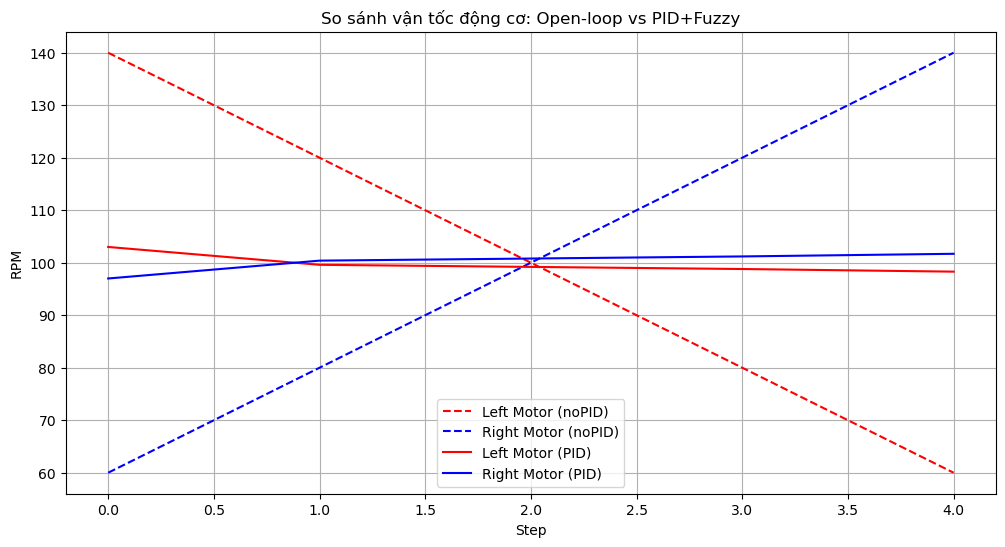

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

class PID:
    def __init__(self, Kp, Ki, Kd):
        self.Kp = Kp
        self.Ki = Ki
        self.Kd = Kd
        self.prev_error = 0
        self.integral = 0

    def fuzzy_tune(self, error, delta_error):
        # rule đơn giản
        if error > 1 and delta_error > 0:
            self.Kp += 0.05
        if abs(error) < 0.5 and delta_error < 0:
            self.Ki += 0.001
        if delta_error > 2:
            self.Kd -= 0.01

        # clamp
        self.Kp = max(self.Kp, 0)
        self.Ki = max(self.Ki, 0)
        self.Kd = max(self.Kd, 0)

    def compute(self, error, dt):
        delta_error = (error - self.prev_error) / dt
        self.fuzzy_tune(error, delta_error)

        self.integral += error * dt
        output = self.Kp * error + self.Ki * self.integral + self.Kd * delta_error
        self.prev_error = error
        return output


# Giả lập
positions = [-2, -1, 0, 1, 2, 1, 0]
baseSpeed = 100
dt = 0.1

pid = PID(0.5, 0.01, 0.1)

records = []
for step, pos in enumerate(positions):
    state = "Lệch trái" if pos < 0 else "Lệch phải" if pos > 0 else "Giữa"

    # Open-loop (rule cứng)
    left_noPID = baseSpeed - pos*20
    right_noPID = baseSpeed + pos*20

    # PID fuzzy
    out = pid.compute(pos, dt)
    left_PID = baseSpeed - out
    right_PID = baseSpeed + out

    records.append({
        "Step": step,
        "Pos": pos,
        "State": state,
        "RPM_L(noPID)": left_noPID,
        "RPM_R(noPID)": right_noPID,
        "RPM_L(PID)": left_PID,
        "RPM_R(PID)": right_PID,
        "OutPID": out,
        "Kp": pid.Kp,
        "Ki": pid.Ki,
        "Kd": pid.Kd
    })

# In bảng
df = pd.DataFrame(records)
print(df.to_string(index=False))

# Plot
plt.figure(figsize=(12,6))
plt.plot(df["Step"], df["RPM_L(noPID)"], "r--", label="Left Motor (noPID)")
plt.plot(df["Step"], df["RPM_R(noPID)"], "b--", label="Right Motor (noPID)")
plt.plot(df["Step"], df["RPM_L(PID)"], "r-", label="Left Motor (PID)")
plt.plot(df["Step"], df["RPM_R(PID)"], "b-", label="Right Motor (PID)")
plt.xlabel("Step")
plt.ylabel("RPM")
plt.title("So sánh vận tốc động cơ: Open-loop vs PID+Fuzzy")
plt.legend()
plt.grid(True)
plt.show()


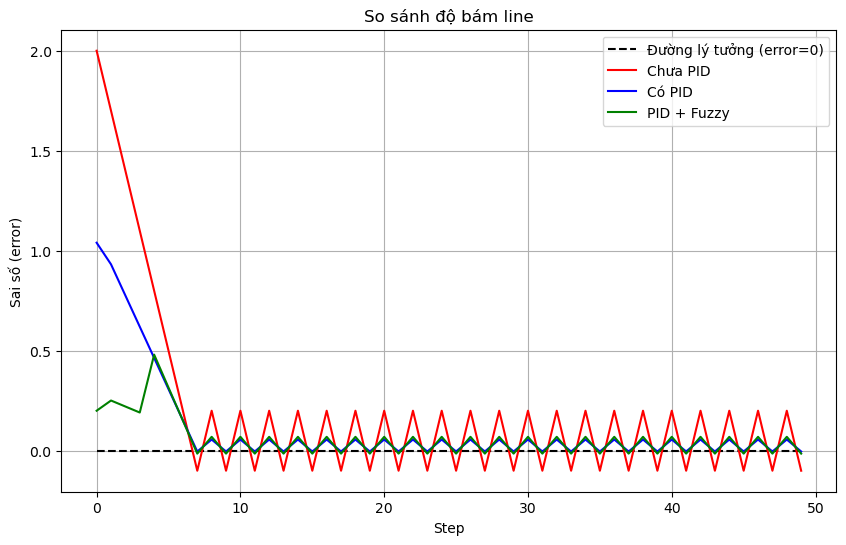

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Tham số mô phỏng
steps = 50
positions = np.zeros(steps)
errors_no_pid = np.zeros(steps)
errors_pid = np.zeros(steps)
errors_fuzzy = np.zeros(steps)

# Giá trị ban đầu
position = 2   # lệch phải nhiều
error_prev = position

# Tham số PID
Kp, Ki, Kd = 0.6, 0.0, 0.2
integral = 0

# Hàm fuzzy chỉnh Kp, Kd
def fuzzy_tune(error, d_error):
    if abs(error) > 1:
        Kp_new = 1.0
        Kd_new = 0.3
    elif abs(d_error) > 1:
        Kp_new = 0.8
        Kd_new = 0.25
    else:
        Kp_new = 0.5
        Kd_new = 0.15
    return Kp_new, Kd_new

# Vòng lặp mô phỏng
for t in range(steps):
    # -------- Lý tưởng --------
    positions[t] = 0  # luôn giữa line

    # -------- Không PID --------
    errors_no_pid[t] = position
    if position > 0:
        position -= 0.3  # xe tự drift về 0 rất chậm
    elif position < 0:
        position += 0.3

    # -------- PID --------
    error = errors_no_pid[t]
    d_error = error - error_prev
    integral += error
    output = Kp*error + Ki*integral + Kd*d_error
    errors_pid[t] = error - output*0.8
    error_prev = error

    # -------- PID + Fuzzy --------
    Kp_f, Kd_f = fuzzy_tune(error, d_error)
    output_f = Kp_f*error + Kd_f*d_error
    errors_fuzzy[t] = error - output_f*0.9

# -------- Vẽ kết quả --------
plt.figure(figsize=(10,6))
plt.plot(np.zeros(steps), 'k--', label="Đường lý tưởng (error=0)")
plt.plot(errors_no_pid, 'r-', label="Chưa PID")
plt.plot(errors_pid, 'b-', label="Có PID")
plt.plot(errors_fuzzy, 'g-', label="PID + Fuzzy")
plt.xlabel("Step")
plt.ylabel("Sai số (error)")
plt.title("So sánh độ bám line")
plt.legend()
plt.grid(True)
plt.show()


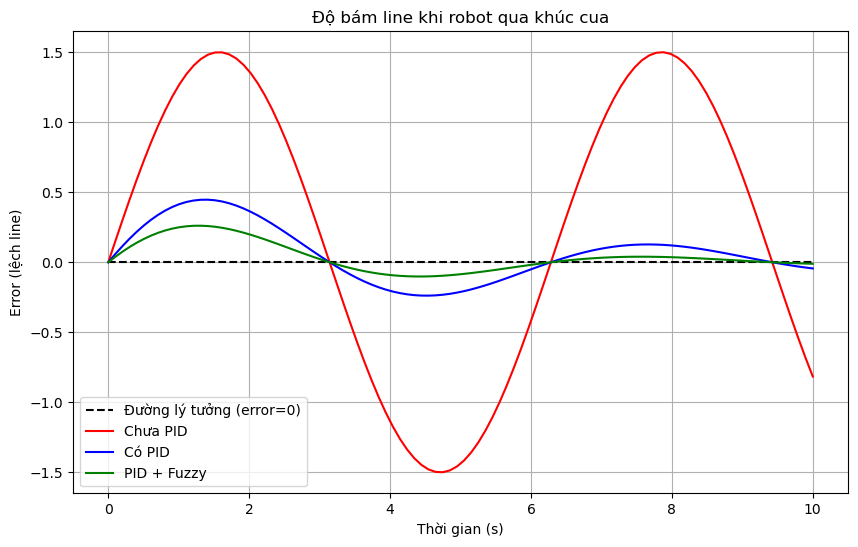


Bảng phân tích error & delta_error (10 bước đầu):
    time  error_no_pid  delta_no_pid  error_pid  delta_pid  error_fuzzy_pid  \
0  0.000         0.000         0.151      0.000      0.059            0.000   
1  0.101         0.151         0.150      0.059      0.058            0.039   
2  0.202         0.301         0.148      0.116      0.055            0.076   
3  0.303         0.448         0.144      0.169      0.051            0.109   
4  0.404         0.590         0.139      0.218      0.047            0.139   
5  0.505         0.726         0.132      0.262      0.043            0.166   
6  0.606         0.854         0.124      0.303      0.038            0.190   
7  0.707         0.974         0.115      0.338      0.033            0.210   
8  0.808         1.084         0.105      0.369      0.028            0.227   
9  0.909         1.183         0.093      0.395      0.023            0.240   

   delta_fuzzy_pid  
0            0.039  
1            0.038  
2            0.0

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Tham số mô phỏng ---
steps = 100
time = np.linspace(0, 10, steps)

# Error "lý tưởng" (robot đi đúng line, error=0)
ideal_error = np.zeros(steps)

# Error chưa PID: lệch mạnh khi vào cua
error_no_pid = np.sin(time) * 1.5  

# Error có PID: bám line tốt hơn, dao động giảm
error_pid = np.sin(time) * 0.6 * np.exp(-0.2*time)  

# Error PID + Fuzzy: tự thích nghi tốt hơn
error_fuzzy_pid = np.sin(time) * 0.4 * np.exp(-0.3*time)

# Delta_error (đạo hàm gần đúng)
delta_no_pid = np.gradient(error_no_pid)
delta_pid = np.gradient(error_pid)
delta_fuzzy_pid = np.gradient(error_fuzzy_pid)

# --- Vẽ đồ thị ---
plt.figure(figsize=(10,6))
plt.plot(time, ideal_error, 'k--', label="Đường lý tưởng (error=0)")
plt.plot(time, error_no_pid, 'r-', label="Chưa PID")
plt.plot(time, error_pid, 'b-', label="Có PID")
plt.plot(time, error_fuzzy_pid, 'g-', label="PID + Fuzzy")

plt.title("Độ bám line khi robot qua khúc cua")
plt.xlabel("Thời gian (s)")
plt.ylabel("Error (lệch line)")
plt.grid(True)
plt.legend()
plt.show()

# --- Vẽ thêm bảng delta_error ---
import pandas as pd
data = {
    "time": time[:10],
    "error_no_pid": error_no_pid[:10],
    "delta_no_pid": delta_no_pid[:10],
    "error_pid": error_pid[:10],
    "delta_pid": delta_pid[:10],
    "error_fuzzy_pid": error_fuzzy_pid[:10],
    "delta_fuzzy_pid": delta_fuzzy_pid[:10],
}
df = pd.DataFrame(data)
print("\nBảng phân tích error & delta_error (10 bước đầu):")
print(df.round(3))
